# 线性拟合：神经网络建模的数学基石

打开AI大模型的黑盒，我们发现神经网络的每一次预测、每一次学习，都建立在最朴素的数学操作之上：**线性拟合**

线性变换是刻画输入空间到特征空间映射的最简数学工具。神经网络之所以将其作为核心构件，根本原因在于：

1. 矩阵乘法与向量加法天然适配现代并行计算架构，且处处光滑可导，为梯度下降与反向传播铺设了无阻碍的优化通道。
2. 通过权重与偏置的线性组合，数据被旋转、缩放并平移至高维表示空间，使原始纠缠的变量逐渐解耦，为后续模式识别提供几何基础。

线性拟合以最简的数学形式，承载了信息流动、维度变换与知识积累的底层逻辑，组成了庞大的神经网络。

# 最小二乘法及其局限性

我们在高中时已经接触过对这种数据进行线性拟合，当时使用的方法是最小二乘法。

数学原理

假设存在一组观测数据点

(x1,y1),(x2,y2),…,(xn,yn) 目标是找到一条直线 y=a*x+b 使其尽可能贴合这些数据点。

最小二乘法通过以下步骤求解参数 a（斜率）和 b（截距）


# 最小二乘法及其局限性

我们在高中时已经接触过对这种数据进行线性拟合，当时使用的方法是最小二乘法。

数学原理

假设存在一组观测数据点 

(x1,y1),(x2,y2),…,(xn,yn) 目标是找到一条直线 $y=ax+b$ 使其尽可能贴合这些数据点。

最小二乘法通过以下步骤求解参数 a（斜率）和 b（截距）

统计

$$\begin{align}
\Sigma_x = \sum_{i=1}^{n} x_i \quad
\Sigma_y = \sum_{i=1}^{n} y_i \quad
\Sigma_{xx} = \sum_{i=1}^{n} x_i^2 \quad
\Sigma_{xy} = \sum_{i=1}^{n} x_i y_i
\end{align}$$

计算

$$\begin{align}
a = \frac{n \cdot \Sigma_{xy} - \Sigma_x \cdot \Sigma_y}{n \cdot \Sigma_{xx} - (\Sigma_x)^2} \quad
b = \frac{\Sigma_y - a \cdot \Sigma_x}{n}
\end{align}$$

下面我们创建一个线性分布的散点图再用最小二乘法进行线性拟合

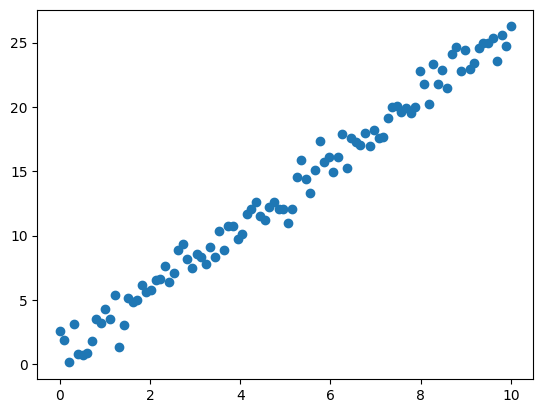

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 自变量
x = np.linspace(0, 10, 100)
# 真实斜率
a_true = 2.5
# 真实截距
b_true = 1.0
# 因变量，加入噪声
y = a_true * x + b_true + np.random.randn(100)

plt.figure()
plt.scatter(x, y, label="Data Points")
plt.show()

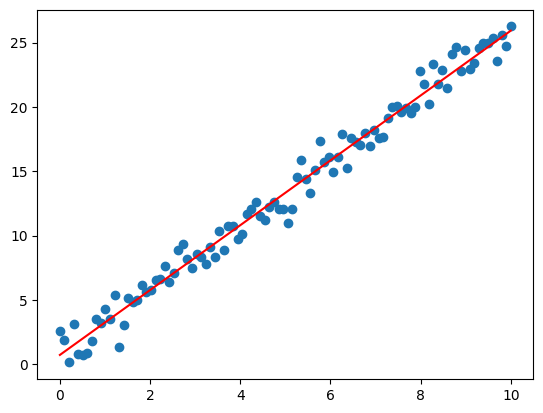

In [5]:
def linear_fit(x: np.ndarray, y: np.ndarray):
    assert len(x) == len(y)
    sigma_x = x.sum()
    sigma_y = y.sum()
    sigma_xx = (x * x).sum()
    sigma_xy = (x * y).sum()
    n = len(x)
    a = (n * sigma_xy - sigma_x * sigma_y) / (n * sigma_xx - sigma_x * sigma_x)
    b = (sigma_y - a * sigma_x) / n
    return a, b


a_hat, b_hat = linear_fit(x, y)

plt.figure()
plt.scatter(x, y, label="Data Points")
plt.plot(x, a_hat * x + b_hat, color="red", label=f"y = {a_hat}*x+{b_hat}")
plt.show()

这一方法表现卓越，但不能用于神经网络

1. 非线性建模的固有缺陷
   最小二乘法本质是线性模型的最优解搜索工具，其闭合解依赖于线性系统的可解析性。
   而神经网络的强大之处在于通过非线性激活函数（如ReLU、Sigmoid）和分层结构实现复杂的非线性映射。
   这种非线性特性使得模型的损失函数（如均方误差）不再是参数的凸函数，导致无法直接通过最小二乘法的闭合解公式求解全局最优。
2. 高维参数空间的计算不可行性
   最小二乘法的闭合解需要计算矩阵的逆。对于神经网络而言，参数量常达数百万甚至数十亿，甚至三千七百亿（deepseek-r1 371B），对应的矩阵维度极高。
   矩阵求逆的运算复杂度为 O(n^3)，这在时间和内存上均不可行。

本系列的前一章节介绍的梯度下降法便是对神经网络进行拟合的核心工具

# 用梯度下降法求解线性拟合问题

本小节继续介绍梯度下降法，与上一章不同，在工程上有很多梯度下降的优化算法，这里介绍BGD与SGD。

## BSD：批量梯度下降（Batch Gradient Descent）

原理：每次迭代使用全部训练样本计算梯度，再统一更新参数。

下面是实现代码

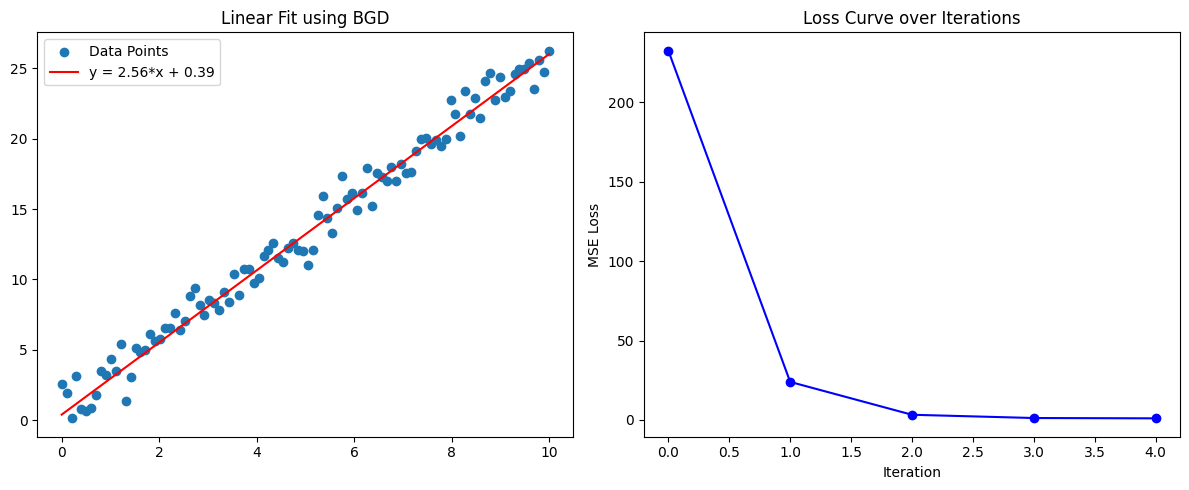

In [13]:
def linear_fit_BGD(
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.01,
    eval_iters: int = 100,
):
    # 初始化参数
    a = 0.0
    b = 0.0
    n = len(x)
    lossi = []

    # 执行梯度下降
    for _ in range(eval_iters):
        # 预测值
        y_pred = a * x + b
        # 计算损失 (MSE)
        loss = np.sum((y_pred - y) ** 2) / n
        lossi.append(loss)
        # 计算梯度
        da = (2 / n) * np.sum((y_pred - y) * x)
        db = (2 / n) * np.sum(y_pred - y)
        # 更新参数
        a -= learning_rate * da
        b -= learning_rate * db
    return a, b, lossi


a_hat_BGD, b_hat_BGD, lossi_BGD = linear_fit_BGD(x, y, 0.01, 5)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(x, y, label="Data Points")
axs[0].plot(x, a_hat_BGD * x + b_hat_BGD, color="red", label=f"y = {a_hat_BGD:.2f}*x + {b_hat_BGD:.2f}")
axs[0].set_title("Linear Fit using BGD")
axs[0].legend()
axs[1].plot(lossi_BGD, marker='o', color='blue')
axs[1].set_title("Loss Curve over Iterations")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("MSE Loss")
plt.tight_layout()
plt.show()

## SGD：随机梯度下降 （Stochastic Gradient Descent）

原理：每次迭代随机选取几个样本计算梯度并立即更新参数。

在上一个实现中，算法每次计算梯度时都会对全部真实值和预测值进行计算

这样做有很多不足之处，首先是计算量很大。其次是梯度一直平滑的下降，可能导致点平滑的陷入局部最优解。

我们可以考虑把数据随机批然后拟合，这样算力消耗会变少，而且引入了一些随机性，使得回归有可能跳出 0 梯度点使参数达到更优秀的效果

在下面的实现，SGD 算法每轮只取 30 条数据回归同样轮数就能达到 BGD 的效果

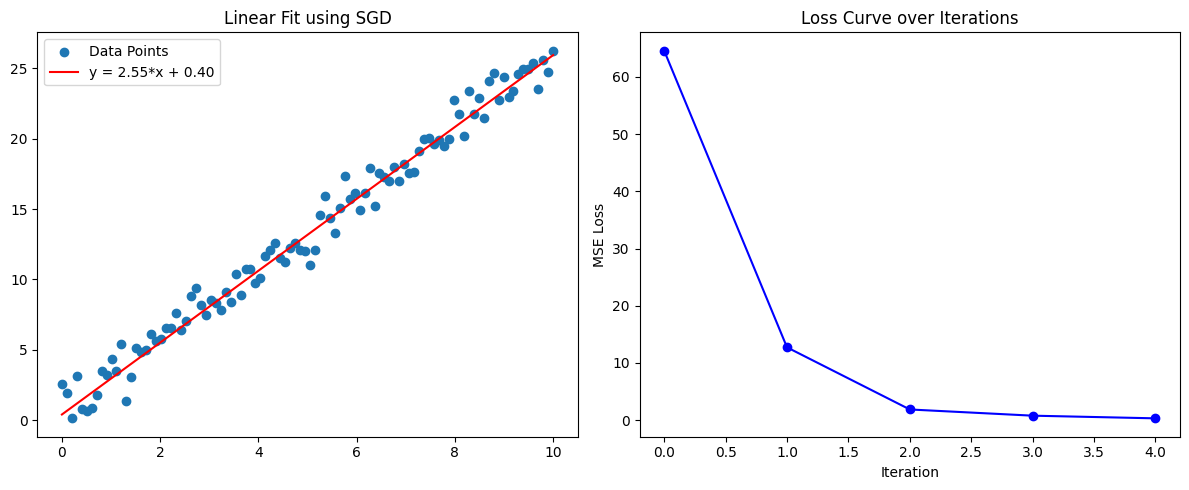

In [14]:
import random


def linear_fit_SGD(
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.01,
    eval_iters: int = 100,
    batch_size: int = 100,
):
    # 初始化参数
    a = 0.0
    b = 0.0
    n = len(x)
    lossi = []
    # 执行梯度下降
    for _ in range(eval_iters):
        ix = random.sample(range(100), batch_size)
        x_batch = x[ix]
        y_batch = y[ix]
        y_pred = a * x_batch + b
        # 计算损失 (MSE)
        loss = np.sum((y_pred - y_batch) ** 2) / n
        lossi.append(loss)
        # 计算梯度
        da = (2 / n) * np.sum((y_pred - y_batch) * x_batch)
        db = (2 / n) * np.sum(y_pred - y_batch)
        # 更新参数
        a -= learning_rate * da
        b -= learning_rate * db
    return a, b, lossi


a_hat_SGD, b_hat_SGD, lossi_SGD = linear_fit_SGD(x, y, 0.03, 5, 30)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(x, y, label="Data Points")
axs[0].plot(x, a_hat_SGD * x + b_hat_SGD, color="red", label=f"y = {a_hat_SGD:.2f}*x + {b_hat_SGD:.2f}")
axs[0].set_title("Linear Fit using SGD")
axs[0].legend()
axs[1].plot(lossi_SGD, marker="o", color="blue")
axs[1].set_title("Loss Curve over Iterations")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("MSE Loss")
plt.tight_layout()
plt.show()

# 梯度下降算法介绍

在工程实现上有如下几种常用的梯度下降算法，此处仅作介绍。

|算法|核心优势|主要缺陷|典型应用场景|
|----|----|----|----|
|BGD|更新稳定，理论分析简单|计算成本高，内存需求大|小规模数据或理论研究|
|SGD|计算高效，适合大规模数据|震荡明显，需精细调参|在线学习、简单模型训练|
|Mini-batch GD|平衡效率与稳定性，硬件加速友好|批量大小需手动选择|深度学习默认优化方式|
|Momentum|加速收敛，减少震荡|需调整动量系数|损失函数地形复杂（如“峡谷”）|
|Adagrad|自适应稀疏特征学习率|学习率过早衰减|NLP、推荐系统|
|RMSprop|动态调整学习率，适合非平稳目标|超参数敏感|RNN、非凸优化|
|Adam|综合性能强，超参数鲁棒性高|可能在某些任务中泛化性略差|深度学习通用优化|

~建议无脑Adam~